# 可选实验：逻辑回归与决策边界

## 目标
在本实验中，您将：
- 绘制逻辑回归模型的决策边界，从而更直观地理解模型正在预测什么。

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from lab_utils_common import plot_data, sigmoid, draw_vthresh
plt.style.use('./deeplearning.mplstyle')

## 数据集

假设你有以下训练数据集：
- 输入变量 `X` 是一个包含 6 个训练样本的 NumPy 数组，每个样本有两个特征
- 输出变量 `y` 也是一个包含 6 个样本的 NumPy 数组，其中 `y` 为 `0` 或 `1`

In [2]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1) 

### 绘制数据

让我们使用辅助函数绘制这些数据。标签为 $y=1$ 的数据点显示为红色叉号，标签为 $y=0$ 的数据点显示为蓝色圆圈。

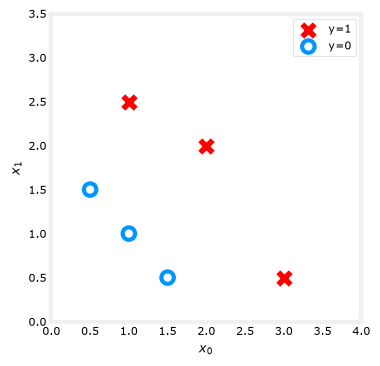

In [4]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
plot_data(X, y, ax)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_0$')
plt.show()

## 逻辑回归模型


* 假设你想在这些数据上训练一个逻辑回归模型，其形式为

  $f(x) = g(w_0x_0+w_1x_1 + b)$
  
  其中，$g(z) = \frac{1}{1+e^{-z}}$ 是 sigmoid 函数


* 假设你训练了模型，并得到参数 $b = -3, w_0 = 1, w_1 = 1$。也就是说，

  $f(x) = g(x_0+x_1-3)$

  （本课程稍后会讲解如何将这些参数拟合到数据）
  
  
让我们绘制模型的决策边界，尝试理解这个训练后的模型会预测什么。

### 逻辑回归与决策边界回顾

* 回想一下，对于逻辑回归，模型表示为

  $$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \tag{1}$$

  其中 $g(z)$ 称为 sigmoid 函数，它将所有输入值映射到 0 和 1 之间：

  $g(z) = \frac{1}{1+e^{-z}}\tag{2}$
  而 $\mathbf{w} \cdot \mathbf{x}$ 是向量点积：
  
  $$\mathbf{w} \cdot \mathbf{x} = w_0 x_0 + w_1 x_1$$
  
  
 * 我们将模型输出（$f_{\mathbf{w},b}(x)$）解释为：在给定 $x$ 且由 $w$ 和 $b$ 参数化的条件下，$y=1$ 的概率。
* 因此，要从逻辑回归模型获得最终预测（$y=0$ 或 $y=1$），可以采用以下启发式规则：

  如果 $f_{\mathbf{w},b}(x) >= 0.5$，预测 $y=1$
  
  如果 $f_{\mathbf{w},b}(x) < 0.5$，预测 $y=0$
  
  
* 让我们绘制 sigmoid 函数，看看 $g(z) >= 0.5$ 所在的位置

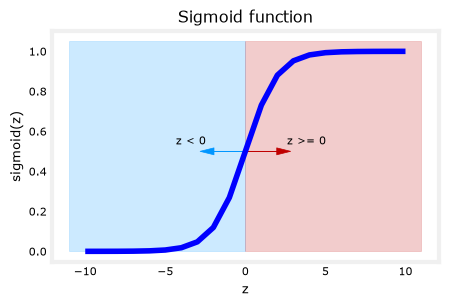

In [5]:
# Plot sigmoid(z) over a range of values from -10 to 10
z = np.arange(-10,11)

fig,ax = plt.subplots(1,1,figsize=(5,3))
# Plot z vs sigmoid(z)
ax.plot(z, sigmoid(z), c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
draw_vthresh(ax,0)

* 可以看到，对于 $z >=0$，$g(z) >= 0.5$

* 对于逻辑回归模型，$z = \mathbf{w} \cdot \mathbf{x} + b$。因此：

  如果 $\mathbf{w} \cdot \mathbf{x} + b >= 0$，模型预测 $y=1$
  
  如果 $\mathbf{w} \cdot \mathbf{x} + b < 0$，模型预测 $y=0$
  
  
  
### 绘制决策边界

现在，让我们回到示例，了解逻辑回归模型如何进行预测。

* 逻辑回归模型的形式为：

  $f(x) = g(-3 + x_0+x_1)$


* 根据上面所学的内容，可以看出，如果 $-3 + x_0+x_1 >= 0$，该模型就会预测 $y=1$

让我们看看它在图形上的表现。我们先绘制 $-3 + x_0+x_1 = 0$，它等价于 $x_1 = 3 - x_0$。

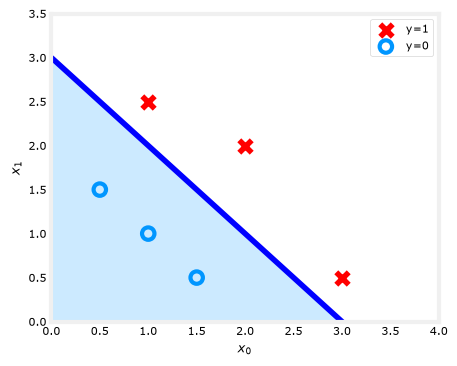

In [6]:
# Choose values between 0 and 6
x0 = np.arange(0,6)

x1 = 3 - x0
fig,ax = plt.subplots(1,1,figsize=(5,4))
# Plot the decision boundary
ax.plot(x0,x1, c="b")
ax.axis([0, 4, 0, 3.5])

# Fill the region below the line
ax.fill_between(x0,x1, alpha=0.2)

# Plot the original data
plot_data(X,y,ax)
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')
plt.show()

* 在上图中，蓝线表示直线 $x_0 + x_1 - 3 = 0$，它应在 3 处与 x1 轴相交（如果设置 $x_1$ = 3、$x_0$ = 0），并在 3 处与 x0 轴相交（如果设置 $x_1$ = 0、$x_0$ = 3）。


* 阴影区域表示 $-3 + x_0+x_1 < 0$。直线上方的区域是 $-3 + x_0+x_1 > 0$。


* 阴影区域（直线下方）中的任何点都被分类为 $y=0$。直线上或直线上方的任何点都被分类为 $y=1$。这条线称为“决策边界”。

如课程中所见，通过使用高阶多项式项（例如 $f(x) = g( x_0^2 + x_1 -1)$），可以得到更复杂的非线性边界。

## 恭喜！
你已经在逻辑回归的背景下探索了决策边界。